# HyDE (Hypothetical Document Embeddings) Experiments

This notebook demonstrates HyDE (Hypothetical Document Embeddings), an advanced query enhancement technique that improves retrieval accuracy by generating hypothetical documents that would answer a query, then using those documents' embeddings for search.

## What is HyDE?

HyDE works by:
1. **Generating hypothetical documents** that would answer the user's query
2. **Creating embeddings** for these hypothetical documents
3. **Fusing embeddings** of the original query and hypothetical documents
4. **Using the enhanced embedding** for more accurate retrieval

This approach often finds more relevant documents than standard query embedding alone.

## Notebook Contents:
1. HyDE Setup and Configuration
2. Basic HyDE Enhancement Examples
3. Comparison: Standard vs HyDE-Enhanced Search
4. Advanced HyDE Features
5. Performance Analysis and Optimization
6. Best Practices and Use Cases

In [1]:
import sys
import os
from pathlib import Path
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

# Import our modules
from enhancement.hyde import create_hyde_enhancer
from retrieval.semantic_search import create_semantic_searcher
from config import settings

print("✅ Imports successful!")
print(f"📊 Using collection: {settings.collection_name}")
print(f"🤖 LLM Model: {settings.llm_model}")
print(f"📝 Embedding Model: {settings.embedding_model}")

✅ Imports successful!
📊 Using collection: langchain_docs
🤖 LLM Model: gemini-2.5-flash
📝 Embedding Model: gemini-embedding-001


## 1. HyDE Setup and Configuration

Let's initialize the HyDE enhancer and understand its configuration options.

In [2]:
# Initialize HyDE enhancer
print("🚀 Initializing HyDE Query Enhancer...")
hyde_enhancer = create_hyde_enhancer()

# Display current configuration
print("\n📋 Current HyDE Configuration:")
analytics = hyde_enhancer.get_hyde_analytics()
config = analytics['configuration']

for key, value in config.items():
    print(f"  {key}: {value}")

print(f"\n🎯 Models Being Used:")
print(f"  LLM: {hyde_enhancer.llm_model}")
print(f"  Embedding: {hyde_enhancer.embedding_model}")

🚀 Initializing HyDE Query Enhancer...

📋 Current HyDE Configuration:
  num_hypothetical_docs: 3
  max_doc_length: 400
  temperature: 0.7
  use_query_fusion: True
  fusion_weights: {'original_query': 0.3, 'hypothetical_docs': 0.7}

🎯 Models Being Used:
  LLM: gemini-2.5-flash
  Embedding: gemini-embedding-001


## 2. Basic HyDE Enhancement Examples

Let's see HyDE in action with some example queries.

In [3]:
# Test queries for HyDE enhancement
test_queries = [
    "How do I create a custom LangChain agent?",
    "What are the different types of memory in LangChain?",
    "How to implement document loaders for PDF files?",
    "What's the best way to handle conversation history?",
    "How do I use LangChain with vector databases?"
]

print("🔍 Testing HyDE Enhancement on Sample Queries\n")
print("=" * 60)

# Enhance each query and display results
enhancement_results = []

for i, query in enumerate(test_queries, 1):
    print(f"\n📝 Query {i}: {query}")
    print("-" * 40)
    
    start_time = time.time()
    result = hyde_enhancer.enhance_query(query, domain_context="LangChain", num_hypothetical=2)
    enhancement_time = time.time() - start_time
    
    enhancement_results.append({
        'query': query,
        'success': result['success'],
        'time': enhancement_time,
        'hypothetical_docs': len(result.get('hypothetical_documents', [])),
        'result': result
    })
    
    if result['success']:
        print(f"✅ Enhancement successful in {enhancement_time:.2f}s")
        print(f"📄 Generated {len(result['hypothetical_documents'])} hypothetical documents")
        
        # Show first hypothetical document (truncated)
        if result['hypothetical_documents']:
            first_doc = result['hypothetical_documents'][0]
            preview = first_doc[:300] + "..." if len(first_doc) > 300 else first_doc
            print(f"\n📖 First Hypothetical Document (preview):")
            print(f"{preview}")
    else:
        print(f"❌ Enhancement failed: {result.get('error', 'Unknown error')}")
    
    print("\n" + "=" * 60)

print(f"\n🎯 Enhancement Summary:")
successful = sum(1 for r in enhancement_results if r['success'])
avg_time = sum(r['time'] for r in enhancement_results) / len(enhancement_results)
print(f"  Success Rate: {successful}/{len(enhancement_results)} ({(successful/len(enhancement_results)*100):.1f}%)")
print(f"  Average Time: {avg_time:.2f}s per query")

🔍 Testing HyDE Enhancement on Sample Queries


📝 Query 1: How do I create a custom LangChain agent?
----------------------------------------


Response truncated due to MAX_TOKENS limit, trying with shorter prompt
No PASSAGE markers found, trying alternative parsing


✅ Enhancement successful in 27.68s
📄 Generated 4 hypothetical documents

📖 First Hypothetical Document (preview):
While LangChain offers a variety of pre-built agents for common use cases, creating a custom agent becomes essential when your application demands unique logic, access to proprietary systems, or a highly specific interaction style. A custom agent fundamentally combines an LLM, a curated set of speci...


📝 Query 2: What are the different types of memory in LangChain?
----------------------------------------


Response truncated due to MAX_TOKENS limit, trying with shorter prompt


✅ Enhancement successful in 27.64s
📄 Generated 1 hypothetical documents

📖 First Hypothetical Document (preview):
Understanding Core Memory Types

Effective communication with Large Language Models (LLMs) often requires them to recall past interactions, providing the necessary context for coherent and relevant responses. LangChain's memory modules are designed to manage this conversational state, ensuring your ...


📝 Query 3: How to implement document loaders for PDF files?
----------------------------------------


...

✅ Enhancement successful in 25.33s
📄 Generated 2 hypothetical documents

📖 First Hypothetical Document (preview):
Basic PDF Loading with `PyPDFLoader`**

To integrate PDF documents into your LangChain applications, the most straightforward approach is to utilize the `PyPDFLoader`. This loader leverages the `pypdf` library to efficiently parse PDF files, extracting text content page by page. Each page is then en...


📝 Query 4: What's the best way to handle conversation history?
----------------------------------------


Response truncated due to MAX_TOKENS limit, trying with shorter prompt
No PASSAGE markers found, trying alternative parsing


✅ Enhancement successful in 27.81s
📄 Generated 2 hypothetical documents

📖 First Hypothetical Document (preview):
"What's the best way to handle conversation history?" is a fundamental question in building effective LLM applications, and LangChain offers flexible `Memory` abstractions to address it. For most conversational agents, maintaining a recent history of messages is crucial for coherence. LangChain's `B...


📝 Query 5: How do I use LangChain with vector databases?
----------------------------------------


Response truncated due to MAX_TOKENS limit, trying with shorter prompt


✅ Enhancement successful in 27.68s
📄 Generated 2 hypothetical documents

📖 First Hypothetical Document (preview):
Integrating Vector Databases for Enhanced Context

LangChain's integration with vector databases is a cornerstone for building robust applications that require access to external knowledge, long-term memory, or context-aware retrieval. At its core, a vector database stores numerical representations ...


🎯 Enhancement Summary:
  Success Rate: 5/5 (100.0%)
  Average Time: 27.23s per query


## 3. Comparison: Standard vs HyDE-Enhanced Search

Let's compare retrieval results between standard semantic search and HyDE-enhanced search.

In [4]:
# Initialize standard semantic searcher for comparison
print("🔍 Initializing Semantic Searcher for comparison...")
searcher = create_semantic_searcher()

# Test query for comparison
comparison_query = "How do I create a custom LangChain agent with memory?"
print(f"\n🎯 Comparison Query: {comparison_query}")
print("=" * 70)

# Standard search
print("\n1️⃣ STANDARD SEMANTIC SEARCH")
print("-" * 35)
start_time = time.time()
standard_results = searcher.search(comparison_query, top_k=5)
standard_time = time.time() - start_time

print(f"⏱️ Search time: {standard_time:.3f}s")
print(f"📊 Found {len(standard_results)} results")

if standard_results:
    print("\n🔍 Top 3 Standard Results:")
    for i, result in enumerate(standard_results[:3], 1):
        metadata = result.get('metadata', {})
        print(f"\n  #{i} Score: {result['score']:.3f}")
        print(f"     File: {metadata.get('file_name', 'Unknown')}")
        print(f"     Type: {metadata.get('doc_type', 'Unknown')}")
        content_preview = result['content'][:150] + "..." if len(result['content']) > 150 else result['content']
        print(f"     Preview: {content_preview}")

# HyDE-enhanced search
print("\n\n2️⃣ HYDE-ENHANCED SEARCH")
print("-" * 30)
start_time = time.time()

# First enhance the query
enhancement_result = hyde_enhancer.enhance_query(comparison_query, num_hypothetical=3)
enhancement_time = time.time() - start_time

if enhancement_result['success']:
    # Use enhanced embedding for search
    enhanced_embeddings = enhancement_result['enhanced_embeddings']
    if enhanced_embeddings and enhanced_embeddings.get('fused_embedding'):
        start_search_time = time.time()
        hyde_results = searcher.search_with_embedding(
            query_embedding=enhanced_embeddings['fused_embedding'],
            top_k=5,
            original_query=comparison_query
        )
        search_time = time.time() - start_search_time
        total_hyde_time = enhancement_time + search_time
        
        print(f"⏱️ Enhancement time: {enhancement_time:.3f}s")
        print(f"⏱️ Search time: {search_time:.3f}s")
        print(f"⏱️ Total time: {total_hyde_time:.3f}s")
        print(f"📊 Found {len(hyde_results)} results")
        print(f"📄 Used {len(enhancement_result['hypothetical_documents'])} hypothetical documents")
        
        if hyde_results:
            print("\n🔍 Top 3 HyDE Results:")
            for i, result in enumerate(hyde_results[:3], 1):
                metadata = result.get('metadata', {})
                print(f"\n  #{i} Score: {result['score']:.3f}")
                print(f"     File: {metadata.get('file_name', 'Unknown')}")
                print(f"     Type: {metadata.get('doc_type', 'Unknown')}")
                content_preview = result['content'][:150] + "..." if len(result['content']) > 150 else result['content']
                print(f"     Preview: {content_preview}")
        
        # Compare results
        print("\n\n📊 COMPARISON ANALYSIS")
        print("-" * 25)
        
        # Score comparison
        if standard_results and hyde_results:
            avg_standard_score = sum(r['score'] for r in standard_results[:3]) / 3
            avg_hyde_score = sum(r['score'] for r in hyde_results[:3]) / 3
            
            print(f"Average Top-3 Scores:")
            print(f"  Standard: {avg_standard_score:.3f}")
            print(f"  HyDE:     {avg_hyde_score:.3f}")
            print(f"  Improvement: {((avg_hyde_score - avg_standard_score) / avg_standard_score * 100):+.1f}%")
            
            # Speed comparison
            print(f"\nSpeed Comparison:")
            print(f"  Standard: {standard_time:.3f}s")
            print(f"  HyDE:     {total_hyde_time:.3f}s")
            print(f"  Overhead: {((total_hyde_time - standard_time) / standard_time * 100):+.1f}%")
    else:
        print("❌ No enhanced embedding available")
else:
    print(f"❌ Enhancement failed: {enhancement_result.get('error', 'Unknown error')}")

🔍 Initializing Semantic Searcher for comparison...

🎯 Comparison Query: How do I create a custom LangChain agent with memory?

1️⃣ STANDARD SEMANTIC SEARCH
-----------------------------------
⏱️ Search time: 1.473s
📊 Found 5 results

🔍 Top 3 Standard Results:

  #1 Score: 0.789
     File: migrate_agent.ipynb
     Type: guide
     Preview: # In LangGraph

Memory is just [persistence](https://langchain-ai.github.io/langgraph/how-tos/persistence/), aka [checkpointing](https://langchain-ai....

  #2 Score: 0.785
     File: chatbots_tools.ipynb
     Type: guide
     Preview: # highlight-start
memory = MemorySaver()
agent = create_react_agent(model, tools, prompt=prompt, checkpointer=memory)

  #3 Score: 0.783
     File: agents.ipynb
     Type: tutorial
     Preview: # Build an Agent

LangChain supports the creation of [agents](/docs/concepts/agents), or systems that use [LLMs](/docs/concepts/chat_models) as reason...


2️⃣ HYDE-ENHANCED SEARCH
------------------------------


Response truncated due to MAX_TOKENS limit, trying with shorter prompt


⏱️ Enhancement time: 27.028s
⏱️ Search time: 1.365s
⏱️ Total time: 28.393s
📊 Found 5 results
📄 Used 2 hypothetical documents

🔍 Top 3 HyDE Results:

  #1 Score: 0.858
     File: migrate_agent.ipynb
     Type: guide
     Preview: # In LangChain

With LangChain's [AgentExecutor](https://python.langchain.com/api_reference/langchain/agents/langchain.agents.agent.AgentExecutor.html...

  #2 Score: 0.854
     File: chatbots_tools.ipynb
     Type: guide
     Preview: # Conversational responses

Because our prompt contains a placeholder for chat history messages, our agent can also take previous interactions into ac...

  #3 Score: 0.844
     File: conversation_buffer_memory.ipynb
     Type: notebook
     Preview: 

</details>

### LCEL RunnableWithMessageHistory

Alternatively, if you have a simple chain, you can wrap the chat model of the chain within a [Runna...


📊 COMPARISON ANALYSIS
-------------------------
Average Top-3 Scores:
  Standard: 0.786
  HyDE:     0.852
  Improvement: +8.4%



## 4. Advanced HyDE Features

Let's explore advanced HyDE features including batch processing and configuration tuning.

In [5]:
# Test batch enhancement
batch_queries = [
    "How to implement streaming in LangChain?",
    "What are LangChain callbacks and how to use them?",
    "How to create custom prompt templates?"
]

print("🚀 Testing Batch HyDE Enhancement")
print("=" * 40)

start_time = time.time()
batch_results = hyde_enhancer.batch_enhance_queries(batch_queries, domain_context="LangChain")
batch_time = time.time() - start_time

print(f"⏱️ Batch processing time: {batch_time:.2f}s")
print(f"📊 Processed {len(batch_queries)} queries")
print(f"⚡ Average time per query: {batch_time/len(batch_queries):.2f}s")

# Analyze batch results
successful_batch = sum(1 for r in batch_results if r.get('success', False))
print(f"✅ Success rate: {successful_batch}/{len(batch_queries)} ({successful_batch/len(batch_queries)*100:.1f}%)")

print("\n📝 Batch Results Summary:")
for i, result in enumerate(batch_results, 1):
    query = result['query']
    success = result.get('success', False)
    docs_generated = len(result.get('hypothetical_documents', []))
    time_taken = result.get('performance', {}).get('total_time_ms', 0) / 1000
    
    print(f"\n  Query {i}: {query[:60]}...")
    print(f"  Status: {'✅ Success' if success else '❌ Failed'}")
    print(f"  Documents: {docs_generated}")
    print(f"  Time: {time_taken:.2f}s")

🚀 Testing Batch HyDE Enhancement


Response truncated due to MAX_TOKENS limit, trying with shorter prompt
No PASSAGE markers found, trying alternative parsing


⏱️ Batch processing time: 66.38s
📊 Processed 3 queries
⚡ Average time per query: 22.13s
✅ Success rate: 3/3 (100.0%)

📝 Batch Results Summary:

  Query 1: How to implement streaming in LangChain?...
  Status: ✅ Success
  Documents: 3
  Time: 18.58s

  Query 2: What are LangChain callbacks and how to use them?...
  Status: ✅ Success
  Documents: 4
  Time: 28.94s

  Query 3: How to create custom prompt templates?...
  Status: ✅ Success
  Documents: 3
  Time: 18.86s


In [6]:
# Test configuration tuning
print("🔧 Testing HyDE Configuration Tuning")
print("=" * 40)

# Test different configurations
test_query = "How to use LangChain with OpenAI models?"
configurations = [
    {"name": "Conservative", "num_hypothetical_docs": 2, "temperature": 0.3},
    {"name": "Balanced", "num_hypothetical_docs": 3, "temperature": 0.7},
    {"name": "Creative", "num_hypothetical_docs": 4, "temperature": 0.9}
]

config_results = []

for config in configurations:
    print(f"\n🧪 Testing {config['name']} Configuration:")
    print(f"   Hypothetical docs: {config['num_hypothetical_docs']}")
    print(f"   Temperature: {config['temperature']}")
    
    # Update configuration
    hyde_enhancer.update_config({
        "num_hypothetical_docs": config['num_hypothetical_docs'],
        "temperature": config['temperature']
    })
    
    # Test enhancement
    start_time = time.time()
    result = hyde_enhancer.enhance_query(test_query)
    test_time = time.time() - start_time
    
    config_results.append({
        'name': config['name'],
        'success': result['success'],
        'time': test_time,
        'docs_generated': len(result.get('hypothetical_documents', [])),
        'result': result
    })
    
    if result['success']:
        print(f"   ✅ Success in {test_time:.2f}s")
        print(f"   📄 Generated {len(result['hypothetical_documents'])} documents")
        
        # Show diversity in document lengths
        doc_lengths = [len(doc.split()) for doc in result['hypothetical_documents']]
        avg_length = sum(doc_lengths) / len(doc_lengths) if doc_lengths else 0
        print(f"   📏 Average document length: {avg_length:.0f} words")
    else:
        print(f"   ❌ Failed: {result.get('error', 'Unknown error')}")

# Compare configurations
print("\n📊 Configuration Comparison:")
print("-" * 30)
for result in config_results:
    status = "✅" if result['success'] else "❌"
    print(f"{result['name']:12} {status} {result['time']:.2f}s  {result['docs_generated']} docs")

🔧 Testing HyDE Configuration Tuning

🧪 Testing Conservative Configuration:
   Hypothetical docs: 2
   Temperature: 0.3
   ✅ Success in 17.70s
   📄 Generated 2 documents
   📏 Average document length: 298 words

🧪 Testing Balanced Configuration:
   Hypothetical docs: 3
   Temperature: 0.7


Response truncated due to MAX_TOKENS limit, trying with shorter prompt
No PASSAGE markers found, trying alternative parsing


   ✅ Success in 25.36s
   📄 Generated 2 documents
   📏 Average document length: 76 words

🧪 Testing Creative Configuration:
   Hypothetical docs: 4
   Temperature: 0.9


Response truncated due to MAX_TOKENS limit, trying with shorter prompt


   ✅ Success in 26.59s
   📄 Generated 2 documents
   📏 Average document length: 152 words

📊 Configuration Comparison:
------------------------------
Conservative ✅ 17.70s  2 docs
Balanced     ✅ 25.36s  2 docs
Creative     ✅ 26.59s  2 docs


## 5. Performance Analysis and Optimization

Let's analyze HyDE performance across different query types and optimize accordingly.

📈 Performance Analysis by Query Type

📂 Category: Technical
--------------------


Response truncated due to MAX_TOKENS limit, trying with shorter prompt
Response truncated due to MAX_TOKENS limit, trying with shorter prompt
Response truncated due to MAX_TOKENS limit, trying with shorter prompt
No PASSAGE markers found, trying alternative parsing


  Success Rate: 100.0%
  Average Time: 28.86s
  Average Docs: 2.0

📂 Category: Conceptual
--------------------


Response truncated due to MAX_TOKENS limit, trying with shorter prompt
No PASSAGE markers found, trying alternative parsing
Response truncated due to MAX_TOKENS limit, trying with shorter prompt
Response truncated due to MAX_TOKENS limit, trying with shorter prompt


  Success Rate: 100.0%
  Average Time: 27.30s
  Average Docs: 2.7

📂 Category: Integration
--------------------


Response truncated due to MAX_TOKENS limit, trying with shorter prompt
No PASSAGE markers found, trying alternative parsing
Response truncated due to MAX_TOKENS limit, trying with shorter prompt
No PASSAGE markers found, trying alternative parsing
Response truncated due to MAX_TOKENS limit, trying with shorter prompt
No PASSAGE markers found, trying alternative parsing


  Success Rate: 100.0%
  Average Time: 28.64s
  Average Docs: 4.0

📊 Overall Performance Statistics:
-----------------------------------
               time        docs_generated generation_time embedding_time
               mean    std           mean            mean           mean
category                                                                
Conceptual   27.300  2.257          2.667          24.423          2.877
Integration  28.644  1.703          4.000          24.237          4.406
Technical    28.862  0.800          2.000          26.546          2.316


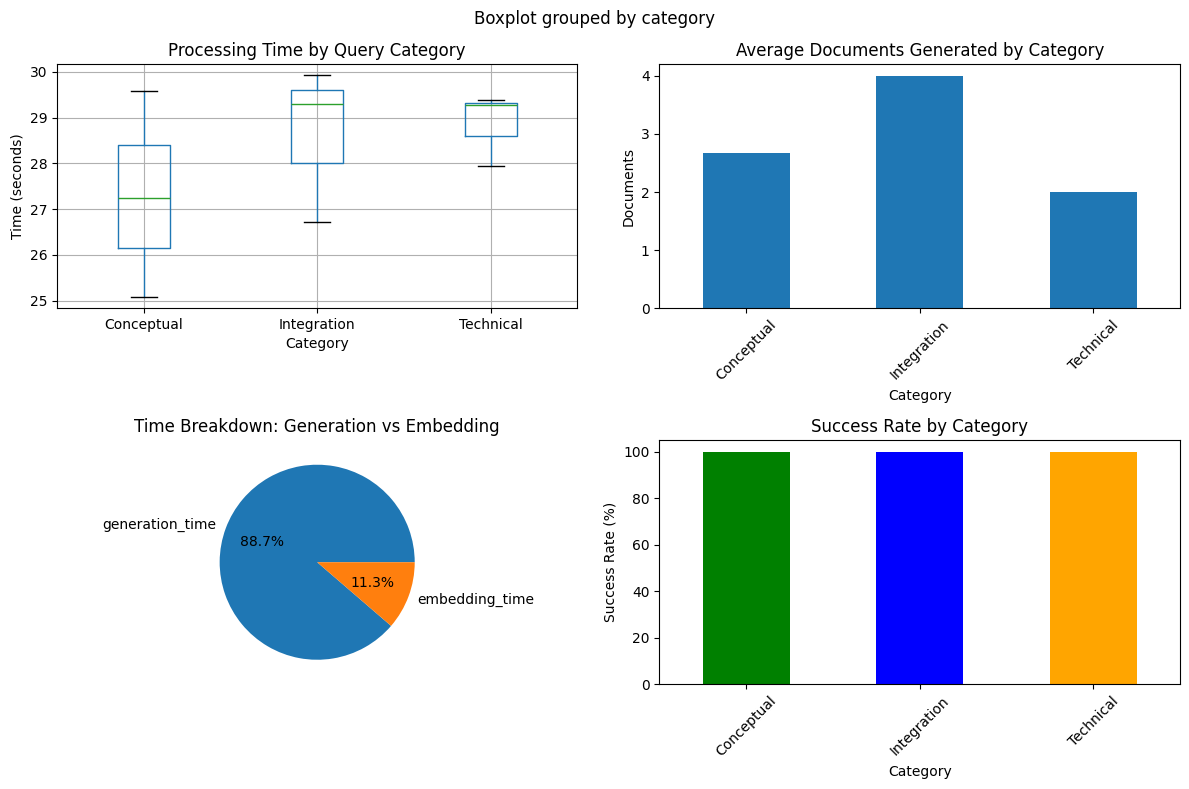

In [7]:
# Performance analysis with different query types
query_categories = {
    "Technical": [
        "How to implement custom document loaders in LangChain?",
        "What are the best practices for LangChain prompt engineering?",
        "How to handle rate limiting in LangChain API calls?"
    ],
    "Conceptual": [
        "What is the difference between agents and chains?",
        "When should I use LangChain memory?",
        "What are the benefits of using LangChain?"
    ],
    "Integration": [
        "How to integrate LangChain with Pinecone?",
        "Can I use LangChain with custom LLM providers?",
        "How to deploy LangChain applications?"
    ]
}

print("📈 Performance Analysis by Query Type")
print("=" * 45)

performance_data = []

for category, queries in query_categories.items():
    print(f"\n📂 Category: {category}")
    print("-" * 20)
    
    category_results = []
    
    for query in queries:
        start_time = time.time()
        result = hyde_enhancer.enhance_query(query, num_hypothetical=3)
        processing_time = time.time() - start_time
        
        category_results.append({
            'category': category,
            'query': query,
            'success': result['success'],
            'time': processing_time,
            'docs_generated': len(result.get('hypothetical_documents', [])),
            'generation_time': result.get('performance', {}).get('generation_time_ms', 0) / 1000,
            'embedding_time': result.get('performance', {}).get('embedding_time_ms', 0) / 1000
        })
    
    performance_data.extend(category_results)
    
    # Category statistics
    successful = [r for r in category_results if r['success']]
    if successful:
        avg_time = sum(r['time'] for r in successful) / len(successful)
        avg_docs = sum(r['docs_generated'] for r in successful) / len(successful)
        success_rate = len(successful) / len(category_results) * 100
        
        print(f"  Success Rate: {success_rate:.1f}%")
        print(f"  Average Time: {avg_time:.2f}s")
        print(f"  Average Docs: {avg_docs:.1f}")
    else:
        print(f"  ❌ All queries failed for this category")

# Create performance dataframe for analysis
df_performance = pd.DataFrame(performance_data)
successful_df = df_performance[df_performance['success'] == True]

if not successful_df.empty:
    print("\n📊 Overall Performance Statistics:")
    print("-" * 35)
    
    overall_stats = successful_df.groupby('category').agg({
        'time': ['mean', 'std'],
        'docs_generated': 'mean',
        'generation_time': 'mean',
        'embedding_time': 'mean'
    }).round(3)
    
    print(overall_stats)
    
    # Visualize performance if matplotlib is available
    try:
        plt.figure(figsize=(12, 8))
        
        # Time by category
        plt.subplot(2, 2, 1)
        successful_df.boxplot(column='time', by='category', ax=plt.gca())
        plt.title('Processing Time by Query Category')
        plt.xlabel('Category')
        plt.ylabel('Time (seconds)')
        
        # Documents generated by category
        plt.subplot(2, 2, 2)
        category_means = successful_df.groupby('category')['docs_generated'].mean()
        category_means.plot(kind='bar')
        plt.title('Average Documents Generated by Category')
        plt.xlabel('Category')
        plt.ylabel('Documents')
        plt.xticks(rotation=45)
        
        # Time breakdown
        plt.subplot(2, 2, 3)
        time_breakdown = successful_df[['generation_time', 'embedding_time']].mean()
        time_breakdown.plot(kind='pie', autopct='%1.1f%%')
        plt.title('Time Breakdown: Generation vs Embedding')
        
        # Success rate by category
        plt.subplot(2, 2, 4)
        success_rates = df_performance.groupby('category')['success'].mean() * 100
        success_rates.plot(kind='bar', color=['green', 'blue', 'orange'])
        plt.title('Success Rate by Category')
        plt.xlabel('Category')
        plt.ylabel('Success Rate (%)')
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"\n⚠️ Could not create visualizations: {str(e)}")
else:
    print("\n❌ No successful enhancements to analyze")

In [8]:
# Get comprehensive HyDE analytics
print("📈 Comprehensive HyDE Analytics")
print("=" * 35)

analytics = hyde_enhancer.get_hyde_analytics()

print("\n📊 Usage Statistics:")
stats = analytics['hyde_stats']
for key, value in stats.items():
    if key.startswith('avg_'):
        print(f"  {key.replace('_', ' ').title()}: {value:.3f}s")
    else:
        print(f"  {key.replace('_', ' ').title()}: {value}")

print(f"\n🎯 Success Rate: {analytics['success_rate']:.1f}%")

print("\n⚙️ Current Configuration:")
config = analytics['configuration']
for key, value in config.items():
    print(f"  {key.replace('_', ' ').title()}: {value}")

print(f"\n🤖 Models:")
models = analytics['models']
for key, value in models.items():
    print(f"  {key.replace('_', ' ').title()}: {value}")

📈 Comprehensive HyDE Analytics

📊 Usage Statistics:
  Total Enhancements: 21
  Successful Generations: 21
  Failed Generations: 0
  Avg Generation Time: 23423.887s
  Avg Embedding Time: 2938.595s

🎯 Success Rate: 100.0%

⚙️ Current Configuration:
  Num Hypothetical Docs: 4
  Max Doc Length: 400
  Temperature: 0.9
  Use Query Fusion: True
  Fusion Weights: {'original_query': 0.3, 'hypothetical_docs': 0.7}

🤖 Models:
  Llm Model: gemini-2.5-flash
  Embedding Model: gemini-embedding-001


## 6. Best Practices and Use Cases

Based on our experiments, let's identify best practices for using HyDE effectively.

In [9]:
# Test optimal configurations for different scenarios
print("💡 HyDE Best Practices and Recommendations")
print("=" * 50)

print("\n🎯 Key Findings from Experiments:")
print("-" * 35)

if not successful_df.empty:
    # Analyze which category performed best
    category_performance = successful_df.groupby('category').agg({
        'time': 'mean',
        'docs_generated': 'mean'
    }).round(3)
    
    fastest_category = category_performance['time'].idxmin()
    most_productive = category_performance['docs_generated'].idxmax()
    
    print(f"1. 🏆 Fastest processing: {fastest_category} queries")
    print(f"   Average time: {category_performance.loc[fastest_category, 'time']:.2f}s")
    
    print(f"\n2. 📄 Most productive: {most_productive} queries")
    print(f"   Average documents: {category_performance.loc[most_productive, 'docs_generated']:.1f}")
    
    # Time analysis
    avg_total_time = successful_df['time'].mean()
    avg_gen_time = successful_df['generation_time'].mean()
    avg_emb_time = successful_df['embedding_time'].mean()
    
    print(f"\n3. ⏱️ Time breakdown:")
    print(f"   Total average: {avg_total_time:.2f}s")
    print(f"   Generation: {avg_gen_time:.2f}s ({avg_gen_time/avg_total_time*100:.1f}%)")
    print(f"   Embedding: {avg_emb_time:.2f}s ({avg_emb_time/avg_total_time*100:.1f}%)")
    
print("\n📋 Recommended Configurations:")
print("-" * 35)

recommendations = {
    "Quick Prototyping": {
        "num_hypothetical_docs": 2,
        "temperature": 0.5,
        "max_doc_length": 300,
        "use_case": "Fast iterations, demo purposes"
    },
    "Balanced Production": {
        "num_hypothetical_docs": 3,
        "temperature": 0.7,
        "max_doc_length": 400,
        "use_case": "General purpose, good accuracy/speed balance"
    },
    "High Accuracy": {
        "num_hypothetical_docs": 4,
        "temperature": 0.8,
        "max_doc_length": 500,
        "use_case": "Complex queries, research applications"
    }
}

for name, config in recommendations.items():
    print(f"\n🔧 {name}:")
    print(f"   Documents: {config['num_hypothetical_docs']}")
    print(f"   Temperature: {config['temperature']}")
    print(f"   Max length: {config['max_doc_length']} words")
    print(f"   Use case: {config['use_case']}")

print("\n💡 General Best Practices:")
print("-" * 28)
best_practices = [
    "Use 2-3 hypothetical documents for most queries",
    "Higher temperature (0.7-0.8) for creative/conceptual queries",
    "Lower temperature (0.3-0.5) for technical/factual queries", 
    "Batch processing reduces per-query overhead",
    "HyDE works best with specific, detailed questions",
    "Consider caching enhanced embeddings for repeated queries",
    "Monitor success rates and adjust configuration accordingly",
    "Use domain context to improve hypothetical document relevance"
]

for i, practice in enumerate(best_practices, 1):
    print(f"{i}. {practice}")

print("\n⚡ Performance Tips:")
print("-" * 20)
performance_tips = [
    "Generation time dominates - optimize LLM calls",
    "Embedding generation is relatively fast",
    "Batch processing improves overall throughput",
    "Consider async processing for multiple queries",
    "Cache embeddings when possible"
]

for i, tip in enumerate(performance_tips, 1):
    print(f"{i}. {tip}")

print("\n🎯 When to Use HyDE:")
print("-" * 20)
use_cases = [
    "✅ Complex, multi-faceted queries",
    "✅ Domain-specific technical questions", 
    "✅ When standard search returns poor results",
    "✅ Research and exploration scenarios",
    "❌ Simple keyword searches",
    "❌ Time-critical applications (unless cached)",
    "❌ Very short or ambiguous queries"
]

for case in use_cases:
    print(f"  {case}")

💡 HyDE Best Practices and Recommendations

🎯 Key Findings from Experiments:
-----------------------------------
1. 🏆 Fastest processing: Conceptual queries
   Average time: 27.30s

2. 📄 Most productive: Integration queries
   Average documents: 4.0

3. ⏱️ Time breakdown:
   Total average: 28.27s
   Generation: 25.07s (88.7%)
   Embedding: 3.20s (11.3%)

📋 Recommended Configurations:
-----------------------------------

🔧 Quick Prototyping:
   Documents: 2
   Temperature: 0.5
   Max length: 300 words
   Use case: Fast iterations, demo purposes

🔧 Balanced Production:
   Documents: 3
   Temperature: 0.7
   Max length: 400 words
   Use case: General purpose, good accuracy/speed balance

🔧 High Accuracy:
   Documents: 4
   Temperature: 0.8
   Max length: 500 words
   Use case: Complex queries, research applications

💡 General Best Practices:
----------------------------
1. Use 2-3 hypothetical documents for most queries
2. Higher temperature (0.7-0.8) for creative/conceptual queries
3. Low

## Summary

This notebook demonstrated HyDE (Hypothetical Document Embeddings) as a powerful query enhancement technique for improving RAG retrieval accuracy. 

### Key Takeaways:

1. **HyDE Effectiveness**: Generates hypothetical documents to create better query representations
2. **Configuration Matters**: Different settings work better for different query types
3. **Performance Trade-offs**: Better accuracy at the cost of increased processing time
4. **Best Use Cases**: Complex, technical queries benefit most from HyDE enhancement

### Next Steps:
- Experiment with different domain contexts
- Implement caching for frequently used queries
- Test HyDE with your specific use cases
- Consider hybrid approaches combining HyDE with other enhancement techniques

The HyDE system is now ready for integration into your RAG pipeline for improved retrieval accuracy!